# Tema 2

# Transformaciones de intensidad



In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## 1. Ampliación del rango dinámico

En primer lugar vamos a comenzar programando una función que reciba una imagen. A continuación, el programa debe calcular el rango dinámico de la imagen y mostrarlo por pantalla. Por último, el programa debe crear una nueva imagen aplicando una transformación de intensidades con el objetivo de ampliar el rango dinámico. Para ello, recuerda que si el rango dinámico de la imagen original es $[a_l,a_h]$, el rango dinámico de la imagen transformada debe ser $[0,255]$. Para realizar este programa varios a realizar varias versiones del mismo:

- Versión 1: Crear un programa formado por dos bucles for  anidados. El for  exterior iterará sobre el número de filas y el for  interior lo hará sobre el número de columnas de la imagen. En cada iteración se modificará cada uno de los píxeles de la imagen


In [13]:
def ampliacion_v1(imagen):
    imagen = np.float32(imagen)
    imagen = imagen / 255
    rango = [imagen.min(), imagen.max()]
    print(f'Rango dinamico {rango[0]*255} , {rango[1]*255}')
    for i in range(imagen.shape[0]):
        for j in range(imagen.shape[1]):
            imagen[i,j] = (imagen[i,j] - rango[0]) *1/(rango[1] - rango[0])
    rango = [imagen.min(), imagen.max()]

    print(f'NUEVO Rango dinamico {rango[0]*255} , {rango[1]*255}')
    return imagen

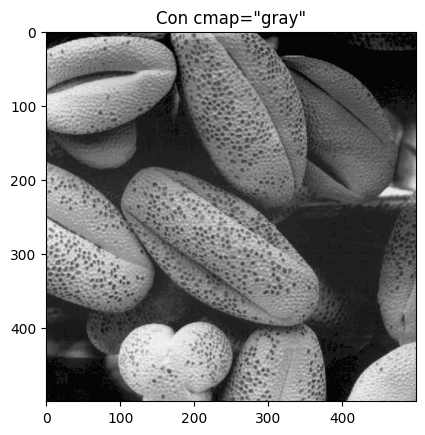

Rango dinamico 90.0 , 138.0
NUEVO Rango dinamico 0.0 , 255.0


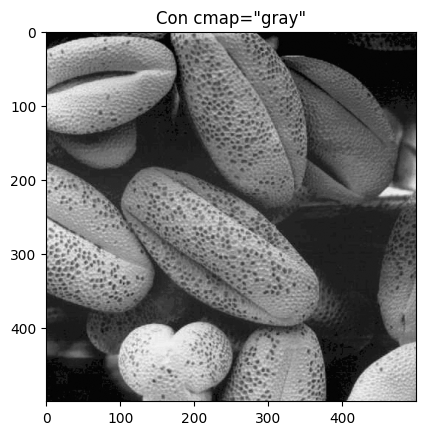

In [14]:
imagen = cv2.imread('images/polen.jpg', 0)
plt.imshow(imagen, cmap='gray')
plt.title('Con cmap="gray"')
plt.show()
imagen2 = ampliacion_v1(imagen)
plt.imshow(imagen2, cmap='gray')
plt.title('Con cmap="gray"')
plt.show()

- Versión 2: Crear un programa que aplique la transformación de intensidad sin utilizar ningún bucle for. 


In [15]:
def ampliacion_v2(imagen):
    imagen = np.float32(imagen)
    imagen = imagen / 255
    rango = [imagen.min(), imagen.max()]
    print(f'Rango dinamico {rango[0]*255} , {rango[1]*255}')
    imagen = (imagen- rango[0]) *1/(rango[1] - rango[0])
    
    rango = [imagen.min(), imagen.max()]

    print(f'NUEVO Rango dinamico {rango[0]*255} , {rango[1]*255}')
    return imagen

Una vez implementada la segunda versión, aplica el programa sobre la imagen polen y compara las dos imágenes (original y transformada). Haz lo mismo con la imagen radiografia. ¿Existe alguna diferencia entre el comportamiento de ambas imágenes? ¿Por qué?

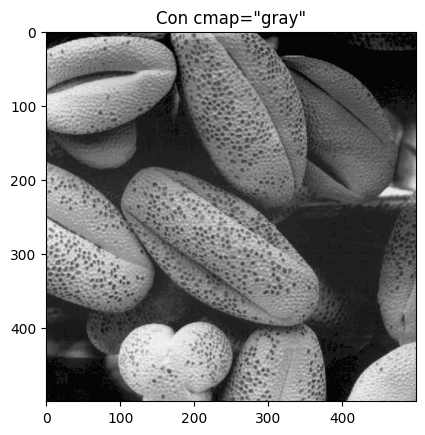

Rango dinamico 90.0 , 138.0
NUEVO Rango dinamico 0.0 , 255.0


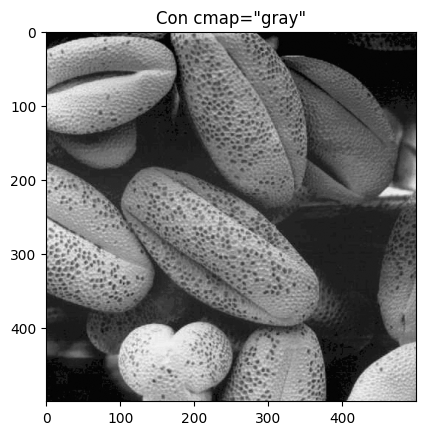

In [16]:
imagen = cv2.imread('images/polen.jpg', 0)
plt.imshow(imagen, cmap='gray')
plt.title('Con cmap="gray"')
plt.show()
imagen2 = ampliacion_v2(imagen)
plt.imshow(imagen2, cmap='gray')
plt.title('Con cmap="gray"')
plt.show()

Rango dinamico 0.0 , 197.0
NUEVO Rango dinamico 0.0 , 255.0


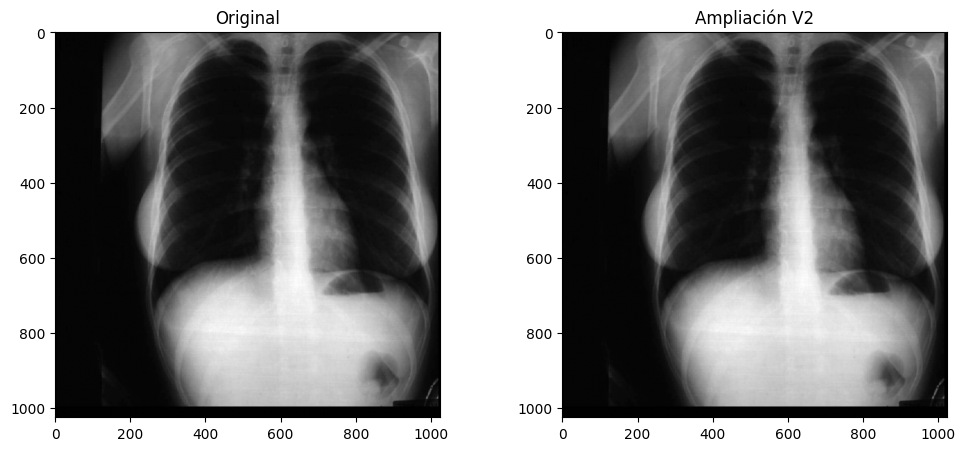

In [17]:
imagen= cv2.imread('images/radiografia.jpg', 0)
imagen2 = ampliacion_v2(imagen)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(imagen, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(imagen2, cmap='gray')
axes[1].set_title('Ampliación V2')
plt.show()

#### Problemas en la ampliación

Aplica tu función `ampliacion_v2` sobre la imagen `polen` y guarda el resultado. A continuación, cambia **un único píxel** de la imagen original (por ejemplo, el de la esquina superior izquierda) poniéndolo a 255 y vuelve a aplicar la misma función.

- ¿Qué le ha pasado a la imagen transformada?
- ¿Cuánto vale el rango dinámico en cada uno de los dos casos?

Propón una nueva implementación de ampliación, `ampliacion_robusta`, que elija dos valores $a_l$ y $a_h$ que no sean el mínimo y el máximo exactos y que aplica la misma fórmula de ampliación pero basada en dichos extremos. Por ejemplo, puedes usar la función `np.percentile` con valores de 5 y 95 (aquellos valores que dejan a su izquierda el 5 y 95\% de valores, respectivamente).  ¿Arreglaría el problema del píxel outlier?

Rango dinamico 90.0 , 138.0
NUEVO Rango dinamico 0.0 , 255.0
Rango dinamico 90.0 , 255.0
NUEVO Rango dinamico 0.0 , 255.0


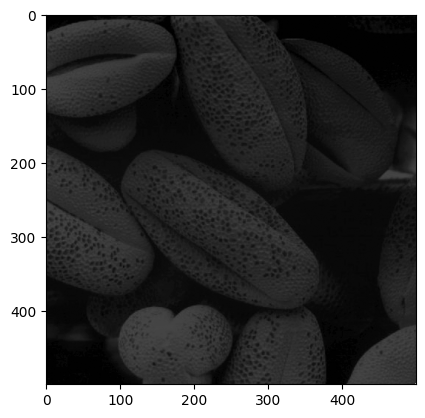

In [18]:
imagen = cv2.imread('images/polen.jpg', 0)
polen2 = ampliacion_v2(imagen)
cv2.imwrite('images/polen2.jpg', polen2*255)
imagen[imagen.shape[0] - 1, imagen.shape[1] - 1] = 255
polen2 = ampliacion_v2(imagen)
#imprimir polen2 con plot
plt.imshow(polen2, cmap='gray')
plt.show()

In [19]:
def ampliacion_robusta(imagen, p = 5):
    imagen = np.float32(imagen)
    imagen = imagen / 255
    print(f'Rango dinamico original: [{imagen.min()*255} , {imagen.max()*255}]')
    rango = [np.percentile(imagen, p), np.percentile(imagen, 100-p)] 
    print(f'Rango dinamico robusto {rango[0]*255} , {rango[1]*255}')
    imagen = (imagen- rango[0])/(rango[1] - rango[0])
    imagen = np.clip(imagen, 0, 1)
    rango = [imagen.min(), imagen.max()]

    print(f'NUEVO Rango dinamico {rango[0]*255} , {rango[1]*255}')
    return imagen

Rango dinamico original: [90.0 , 255.0]
Rango dinamico robusto 91.0 , 129.0
NUEVO Rango dinamico 0.0 , 255.0


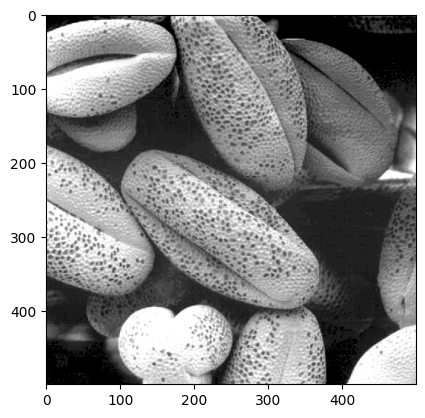

In [20]:
imagen = cv2.imread('images/polen.jpg', 0)
imagen[imagen.shape[0] - 1, imagen.shape[1] - 1] = 255
ampliada = ampliacion_robusta(imagen, p=5)
plt.imshow(ampliada, cmap='gray')
plt.show()

## 2. Ecualización del histograma

En segundo lugar vamos a realizar un programa que reciba una imagen y aplique la transformación de intensidad basada en ecualización del histograma. Para ello, comenzaremos obteniendo el histograma de la imagen de entrada. Si tuviésemos que crear un histograma de manera manual, deberíamos utilizar una función del estilo...

In [21]:
def calculaHistograma(imagen):
    histograma = np.zeros((256))
    filas, columnas = imagen.shape
    for i in range(filas):
        for j in range(columnas):
            histograma[imagen[i,j]] += 1
    return histograma

Sin embargo, estamos utilizando una librería (opencv) con muchas funciones built-in, entre las cuales seguro que se encuentra  una para calcular el histograma. En este caso se denomina calcHist y tiene los siguientes parámetros de entrada:
- images: conjunto de imágenes sobre las que queremos aplicar el histograma. Si solo vamos a calcular el histograma de una sola imagen también debemos colocarla en formato lista (entre corchetes [imagen])
- channels: canales sobre los que queremos calcular el histograma de las imágenes. Si, por ejemplo, la imagen es en escala de grises debemos especificar [0]
- mask: máscara que indica la zona de la imagen de la que queremos obtener el histograma. Si queremos el histograma de toda la imagen escribimos None
- histSize: dimensión del histograma. En este caso es el número de "bins" en los que queremos obtener el histograma. Para obtener un histograma completo, escribir [256]
- range: rango de intensidades para el que queremos obtener el histograma, generalmente [0,256]

In [22]:
imagen = cv2.imread('images/radiografia.jpg', 0)
print(imagen.shape)
print(imagen.size)
h = cv2.calcHist([imagen], [0], None, [256], [0,256]).flatten()
h.sum()

(1024, 1024)
1048576


np.float32(1.048576e+06)

Además de la función calcHist, la propia librería numpy tiene una función llamada histogram() que prácticamente funciona igual. La única diferencia es que np.histogram nos devolverá una tupla: el primer elemento contiene el conteo (histograma) y el segundo contiene los bins utilizados.

In [23]:
imagen = cv2.imread('images/radiografia.jpg', 0)
h, bins = np.histogram(imagen, bins = 256, range = [0,256])
h

array([  8534,  27332,   2218,   2285, 135652,  39348,   4653,  26313,
        40478,   9292,  26343,  27421,  12958,  23720,  18726,  11263,
        13554,  10719,   8473,   8801,   8297,   6533,   6276,   5954,
         5549,   5301,   4649,   4459,   4384,   3898,   3808,   3532,
         3707,   3704,   3735,   3645,   3584,   3364,   2840,   3078,
         3076,   2953,   3085,   3104,   3054,   3118,   3237,   3250,
         3043,   3065,   3181,   3340,   3358,   3544,   3550,   3511,
         3513,   3521,   3470,   3612,   3495,   3455,   3383,   3317,
         3214,   3411,   3216,   3148,   3311,   3211,   3567,   3855,
         3684,   4120,   3690,   3763,   3823,   3654,   3640,   4017,
         4165,   4224,   4572,   4314,   4495,   5128,   4649,   4268,
         4450,   4562,   4252,   4104,   3980,   3717,   3504,   3331,
         3365,   3492,   3699,   3616,   3920,   3630,   3512,   3606,
         3410,   3286,   3142,   3303,   3141,   3339,   3107,   2965,
      

Entonces, ¿existe alguna diferencia? Una de ellas es el tiempo de ejecución. Utilicemos para ello el comando %%time al principio de la celda para analizar el tiempo de ejecución. ¿Hay diferencias?

In [24]:
%%time
imagen = cv2.imread('images/radiografia.jpg', 0)
h = cv2.calcHist([imagen], [0], None, [256], [0,256]).flatten()

CPU times: total: 0 ns
Wall time: 2.84 ms


In [25]:
%%time
imagen = cv2.imread('images/radiografia.jpg', 0)
h, bins = np.histogram(imagen, bins = 256, range = [0,256])

CPU times: total: 15.6 ms
Wall time: 37.6 ms


Una vez entendida la función calcHist, volvamos al problema.
- Versión 1: Crear un programa formado por tres bucles for anidados. Los dos primeros bucles for iteran sobre el número de filas y columnas de la imagen, respectivamente. Para cada píxel de la imagen, vamos a calcular mediante el tercer for la suma de las probabilidades de las intensidades menores que dicho pixel
$$255\sum_{i=0}^{I(x,y)}h_p(i)$$
donde $h_p(i)$ es la probabilidad de la intensidad $i$ en la imagen (histograma normalizado). 

In [26]:
def ecualizacion_v1(imagen):
    """
    Crear un programa formado por tres bucles for anidados. 
    Los dos primeros bucles for iteran sobre el número de filas y columnas 
    de la imagen, respectivamente. Para cada píxel de la imagen, vamos a
    calcular mediante el tercer for la suma 
    de las probabilidades de las intensidades menores que dicho pixel
    """
    h = cv2.calcHist([imagen], [0], None, [256], [0,256]).flatten()
    ecualizada = imagen.copy()
    NM = imagen.shape[0] * imagen.shape[1]
    for i in range(imagen.shape[0]):
        for j in range(imagen.shape[1]):
            suma = 0
            for k in range(imagen[i,j]+1):
                suma += h[k]
            ecualizada[i,j] = suma / (NM) * 255
    return np.uint8(ecualizada)

In [27]:
imagen = cv2.imread('images/radiografia.jpg', 0)
ecualizada = ecualizacion_v1(imagen)

[     0      0   8534      0      0      0      0      0  27332   4503
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0 135652      0      0      0      0      0      0      0
      0      0  39348   4653      0      0      0      0      0  26313
      0      0      0      0      0      0      0      0      0  40478
      0      0   9292      0      0      0      0      0  26343      0
      0      0      0      0      0  27421      0      0  12958      0
      0      0      0      0  23720      0      0      0  18726      0
      0  11263      0      0  13554      0      0  10719      0   8473
      0   8801      0   8297      0   6533   6276   5954      0   5549
   5301   4649   4459   4384   3898   3808   3532   3707   3704   3735
   3645   6948   2840   3078   6029   3085   3104   6172   3237   3250
   610

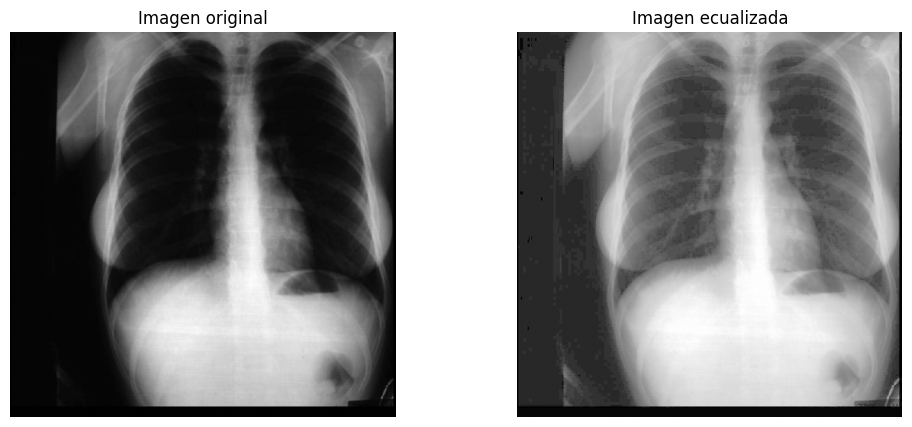

True

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(imagen, cmap='gray')
axes[0].set_title('Imagen original')
axes[0].axis('off')

axes[1].imshow(ecualizada, cmap='gray')
axes[1].set_title('Imagen ecualizada')
axes[1].axis('off')

plt.show()

- Versión 2: Crear un programa que, una vez obtenido el histograma, lo transforme en un función de densidad de probabilidad y a continuación lo transforme en una función de distribución (función de densidad de probabilidad acumulada). A continuación utiliza los dos bucles de filas y columnas para modificar cada píxel: si en la posición (i,j) la imagen tiene intensidad q, entonces cambiar el valor de dicha intensidad por el valor q-ésimo de la función de distribución.


In [34]:
def ecualizacion_v2(imagen):
    #obtenemos el histograma de la imagen
    h = cv2.calcHist([imagen], [0], None, [256], [0,256]).flatten()
    NM = imagen.shape[0] * imagen.shape[1]
    #funcion densidad de probabilidad
    pdf = h / NM
    #funcion de distribucion acumulada
    cdf = np.zeros((256))
    cdf[0] = pdf[0]
    for i in range(1,256):
        cdf[i] = cdf[i-1] + pdf[i]
    #ecualizamos la imagen
    ecualizada = np.zeros_like(imagen)
    for i in range(imagen.shape[0]):
        for j in range(imagen.shape[1]):
            ecualizada[i,j] = cdf[imagen[i,j]] * 255

    return np.uint8(ecualizada)

In [ ]:
imagen = cv2.imread('images/radiografia.jpg', 0)


- Versión 3: ¿Se te ocurre alguna manera de hacer lo mismo que antes pero evitándonos los dos bucles for anidados?


In [ ]:
def ecualizacion_v3(imagen):
    
    return imagen

In [ ]:
imagen = cv2.imread('images/radiografia.jpg', 0)


Una vez finalizadas las 3 opciones, compara los tiempos de ejecución. 



In [ ]:
%%timeit 
imagen2 = ecualizacion_v2(imagen)

In [ ]:
%%timeit 
imagen3 = ecualizacion_v3(imagen)


#### Problemas en la ecualización

Ecualiza la imagen `radiografia` con tu función `ecualizacion_v3` y observa el resultado con calma, prestando atención a las zonas amplias y uniformes. ¿Aparece algo que no se veía en la imagen original? ¿Es información nueva o se han generado cambios de intensidad donde antes no los había? ¿A qué crees que se deben? 


In [ ]:
imagen = cv2.imread('images/radiografia.jpg', 0)

## 3. Histogram matching

La ecualización lleva el histograma a una distribución uniforme. E histogram matching o especificación del histograma gneneraliza la idea: en lugar de un histograma uniforme, el objetivo es el histograma de otra imagen, que llamamos referencia.

Si $H_I$ y $H_R$ son los histogramas acumulados normalizados de la imagen y de la referencia, respectivamente, la transformación de histogram matching viene dada por:

$$f(i) = \min\{\, j \in \{0,\dots,255\} \;\mid\; H_I(i) \leq H_R(j) \,\}$$

Es decir: a cada nivel de gris $i$ le corresponde el primer nivel $j$ de la referencia cuyo acumulado ya ha alcanzado el de $i$. 

Escribe una función `matching` que, reciba los histogramas normalizados de las dos imágenes (original y referencia). La función calculará $H_I$ y $H_R$. A continuación, construirá la LUT (array de 256 valores) que contenga la transformación que aplicaría el histogram matching. 

In [ ]:
def matching(h_I, h_R):
    
    return lut

Una vez hecha esta función, crea la función `histogram_matching` que reciba directamente las dos imágenes y aplique la transformación utilizando la función `matching`. 

In [ ]:
def histogram_matching(imagen, referencia):
    
    return imagen

En la carpeta de imágenes encontrarás dos imágenes  de hoja de vid: una de ellas tiene unas buenas condiciones de adquisición y la otra no. Utiliza histogram matching para mejorar la calidad de la imagen de mala iluminación.

In [ ]:
imagen       = cv2.imread('images/hoja_mal.jpg', 0)
referencia = cv2.imread('images/hoja_bien.jpg', 0)


